In [1]:
# benodigde libraries importeren
import pandas as pd  # voor werken met data
import numpy as np  # voor berekeningen
import matplotlib.pyplot as plt  # voor grafieken
from sklearn.cluster import KMeans  # KMeans model
from sklearn.preprocessing import StandardScaler  # data schalen
from sklearn.metrics import silhouette_score  # silhouette score berekenen
from sklearn.decomposition import PCA  # PCA voor visualisatie
from sklearn.metrics import silhouette_samples  # silhouette per datapunt

In [2]:
file_path = 'AmesHousing.xlsx'  # bestandsnaam
df = pd.read_excel(file_path, sheet_name='AmesHousing')  # juiste sheet inladen
df.head()  # eerste rijen bekijken

,ID,SalePrice,Garage,Overall Qual,Gr Liv Area,Total Bsmt SF,Lot Area,Year Built,Full Bath,Bedroom AbvGr,Neighborhood,House Style
0,1,215000,yes,6,1656,1080.0,31770,1960,1,3,NAmes,1Story
1,2,105000,yes,5,896,882.0,11622,1961,1,2,NAmes,1Story
2,3,172000,yes,6,1329,1329.0,14267,1958,1,3,NAmes,1Story
3,4,244000,yes,7,2110,2110.0,11160,1968,2,3,NAmes,1Story
4,5,189900,yes,5,1629,928.0,13830,1997,2,3,Gilbert,2Story


In [3]:
def run_experiment(features, n_clusters, random_state=42, n_init=10):
    data = df[features].copy()  # gekozen features selecteren
    data = pd.get_dummies(data, drop_first=True)  # categorische kolommen omzetten naar 0/1
    scaler = StandardScaler()  # scaler maken
    scaled = scaler.fit_transform(data)  # data schalen
    model = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=n_init)  # model maken
    labels = model.fit_predict(scaled)  # model trainen en clusterlabels krijgen
    score = silhouette_score(scaled, labels)  # silhouette score berekenen
    return score  # score teruggeven

In [4]:
# Lijst met experimentconfiguraties
experiments = [
    (['Gr Liv Area', 'Overall Qual', 'Neighborhood'], 3),
    (['Gr Liv Area', 'Overall Qual', 'Neighborhood'], 5),
    (['Gr Liv Area', 'Overall Qual', 'Year Built', 'Neighborhood'], 4),
    (['Gr Liv Area', 'Overall Qual', 'Garage', 'Neighborhood'], 6),
    (['Gr Liv Area', 'Overall Qual', 'Garage', 'Full Bath', 'Neighborhood'], 5)
]

results = []  # Opslag resultaten

for features, k in experiments:
    score = run_experiment(features, k)  # Voer experiment uit
    results.append((features, k, score))  # Sla resultaat op

results  # Toon alle resultaten

# extra experimenten cuz of feedback (6 t/m 25)

extra_experiments = []

def run_cluster_experiment(name, features, k, n_init=10, random_state=42):
    data = df[features].copy()
    data = pd.get_dummies(data, drop_first=True)
    scaled = StandardScaler().fit_transform(data)
    
    model = KMeans(
        n_clusters=k,
        random_state=random_state,
        n_init=n_init
    )
    
    labels = model.fit_predict(scaled)
    score = silhouette_score(scaled, labels)
    
    extra_experiments.append({
        "Experiment": name,
        "Features": ", ".join(features),
        "Aantal_features": len(features),
        "k": k,
        "n_init": n_init,
        "Silhouette": score
    })


# Variatie in k (meer clusters)

run_cluster_experiment("Exp 6: k=2", ['Gr Liv Area','Overall Qual','Neighborhood'], 2)
run_cluster_experiment("Exp 7: k=4", ['Gr Liv Area','Overall Qual','Neighborhood'], 4)
run_cluster_experiment("Exp 8: k=6", ['Gr Liv Area','Overall Qual','Neighborhood'], 6)
run_cluster_experiment("Exp 9: k=8", ['Gr Liv Area','Overall Qual','Neighborhood'], 8)

# Meer numerieke features

run_cluster_experiment("Exp 10: +Year Built",
                       ['Gr Liv Area','Overall Qual','Year Built','Neighborhood'], 3)

run_cluster_experiment("Exp 11: +Lot Area",
                       ['Gr Liv Area','Overall Qual','Lot Area','Neighborhood'], 3)

run_cluster_experiment("Exp 12: +Full Bath",
                       ['Gr Liv Area','Overall Qual','Full Bath','Neighborhood'], 3)

# Meer uitgebreide feature set

run_cluster_experiment("Exp 13: uitgebreide set",
                       ['Gr Liv Area','Overall Qual','Year Built',
                        'Lot Area','Full Bath','Neighborhood'], 4)

run_cluster_experiment("Exp 14: uitgebreide set k=5",
                       ['Gr Liv Area','Overall Qual','Year Built',
                        'Lot Area','Full Bath','Neighborhood'], 5)

# Alleen numeriek
run_cluster_experiment("Exp 15: alleen numeriek",
                       ['Gr Liv Area','Overall Qual','Year Built','Lot Area'], 3)

# Alleen 2 features

run_cluster_experiment("Exp 16: 2 features",
                       ['Gr Liv Area','Overall Qual'], 3)

#  Test hogere n_init (stabiliteit)

run_cluster_experiment("Exp 17: n_init=20",
                       ['Gr Liv Area','Overall Qual','Neighborhood'], 3, n_init=20)

run_cluster_experiment("Exp 18: n_init=50",
                       ['Gr Liv Area','Overall Qual','Neighborhood'], 3, n_init=50)

# Andere random_state

run_cluster_experiment("Exp 19: random_state=1",
                       ['Gr Liv Area','Overall Qual','Neighborhood'], 3, random_state=1)

run_cluster_experiment("Exp 20: random_state=100",
                       ['Gr Liv Area','Overall Qual','Neighborhood'], 3, random_state=100)

# Combinatie feature + hogere k

run_cluster_experiment("Exp 21: uitgebreide set k=6",
                       ['Gr Liv Area','Overall Qual','Year Built',
                        'Lot Area','Full Bath','Neighborhood'], 6)

run_cluster_experiment("Exp 22: uitgebreide set k=7",
                       ['Gr Liv Area','Overall Qual','Year Built',
                        'Lot Area','Full Bath','Neighborhood'], 7)


# Extra categorische impact

run_cluster_experiment("Exp 23: +Garage",
                       ['Gr Liv Area','Overall Qual','Garage','Neighborhood'], 4)

run_cluster_experiment("Exp 24: +Garage +Full Bath",
                       ['Gr Liv Area','Overall Qual','Garage',
                        'Full Bath','Neighborhood'], 5)

# Complex model


run_cluster_experiment("Exp 25: veel features k=8",
                       ['Gr Liv Area','Overall Qual','Year Built',
                        'Lot Area','Full Bath','Garage','Neighborhood'], 8)

# Resultaten overzicht
cluster_results_df = pd.DataFrame(extra_experiments).sort_values(
    "Silhouette", ascending=False
).reset_index(drop=True)

display(cluster_results_df)

,Experiment,Features,Aantal_features,k,n_init,Silhouette
0,Exp 15: alleen numeriek,"Gr Liv Area, Overall Qual, Year Built, Lot Area",4,3,10,0.383892
1,Exp 16: 2 features,"Gr Liv Area, Overall Qual",2,3,10,0.383544
2,Exp 9: k=8,"Gr Liv Area, Overall Qual, Neighborhood",3,8,10,0.301465
3,Exp 22: uitgebreide set k=7,"Gr Liv Area, Overall Qual, Year Built, Lot Are...",6,7,10,0.215494
4,Exp 25: veel features k=8,"Gr Liv Area, Overall Qual, Year Built, Lot Are...",7,8,10,0.206669
5,Exp 8: k=6,"Gr Liv Area, Overall Qual, Neighborhood",3,6,10,0.203978
6,Exp 21: uitgebreide set k=6,"Gr Liv Area, Overall Qual, Year Built, Lot Are...",6,6,10,0.171568
7,Exp 7: k=4,"Gr Liv Area, Overall Qual, Neighborhood",3,4,10,0.157043
8,Exp 23: +Garage,"Gr Liv Area, Overall Qual, Garage, Neighborhood",4,4,10,0.140043
9,Exp 24: +Garage +Full Bath,"Gr Liv Area, Overall Qual, Garage, Full Bath, ...",5,5,10,0.133610


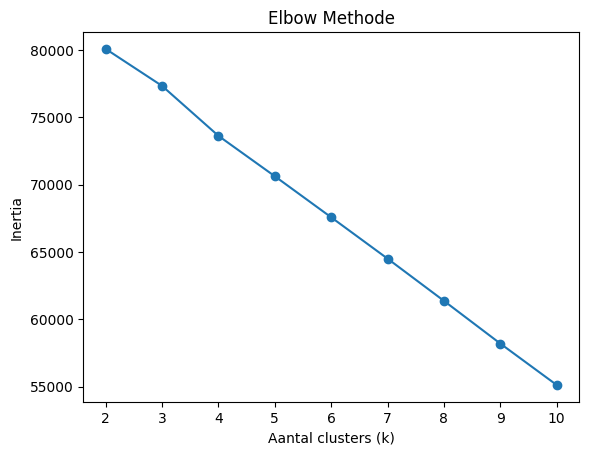

In [5]:
# Elbow methode voor beste k
features = ['Gr Liv Area', 'Overall Qual', 'Neighborhood']  # vaste features
data = pd.get_dummies(df[features], drop_first=True)  # one-hot encoding
scaled = StandardScaler().fit_transform(data)  # data schalen

inertias = []  # lege lijst
K_range = range(2, 11)  # k van 2 t/m 10 testen

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)  # model maken
    model.fit(scaled)  # model trainen
    inertias.append(model.inertia_)  # inertia opslaan

plt.plot(K_range, inertias, marker='o')  # grafiek maken
plt.xlabel('Aantal clusters (k)')  # x-as
plt.ylabel('Inertia')  # y-as
plt.title('Elbow Methode')  # titel
plt.show()  # tonen

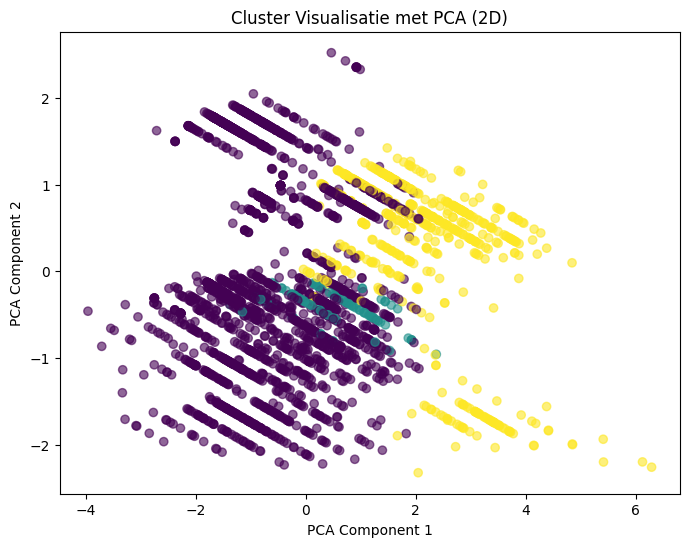

In [15]:
# Kies aantal clusters (bijv. 3 op basis van elbow)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # Initialiseert KMeans met 3 clusters en vaste random state
clusters = kmeans.fit_predict(scaled) # Traint het model en geeft clusterlabels terug

# Importeer PCA
from sklearn.decomposition import PCA # Importeert PCA-functionaliteit

# Reduceer data naar 2 dimensies
pca = PCA(n_components=2) # Maakt PCA-object voor 2 componenten
X_pca = pca.fit_transform(scaled) # Past PCA toe op geschaalde data en slaat resultaat op

# Maak visualisatie
plt.figure(figsize=(8,6)) # Maakt een figuur van 8x6 inch
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis', alpha=0.6) # Plot PCA-punten in 2D gekleurd per cluster met 60% doorzichtigheid
plt.title("Cluster Visualisatie met PCA (2D)") # Zet titel op de plot
plt.xlabel("PCA Component 1") # Labelt x-as
plt.ylabel("PCA Component 2") # Labelt y-as
plt.show() # Toont de plot

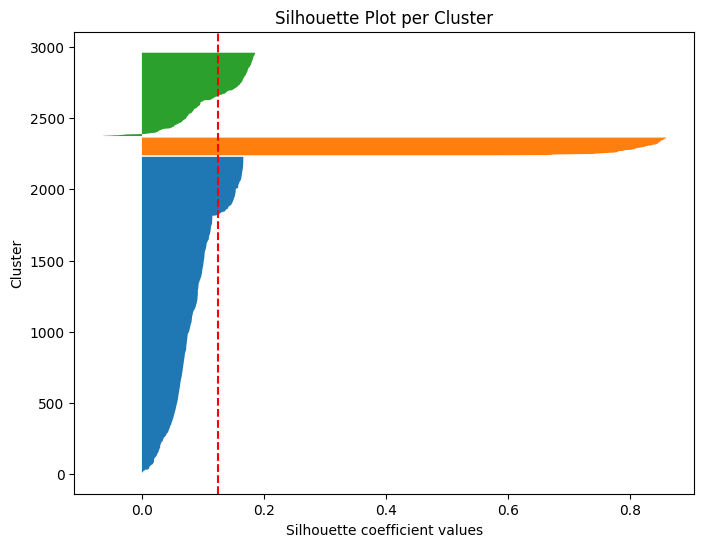

In [7]:
# bereken silhouette per datapunt
sample_silhouette_values = silhouette_samples(scaled, clusters) # berekent silhouette-score voor elk datapunt

n_clusters = len(np.unique(clusters)) # bepaalt aantal unieke clusters
y_lower = 10 # startpositie op y-as voor de eerste cluster

plt.figure(figsize=(8,6)) # maakt een figuur van 8x6 inch

for i in range(n_clusters): # doorloopt elke cluster
 cluster_silhouette_values = sample_silhouette_values[clusters == i] # selecteert silhouette-waarden van huidige cluster
 cluster_silhouette_values.sort() # sorteert waarden oplopend voor de plot

 size_cluster = len(cluster_silhouette_values) # bepaalt grootte van de cluster
 y_upper = y_lower + size_cluster # berekent bovenste grens op y-as voor deze cluster

 plt.fill_betweenx(np.arange(y_lower, y_upper), # vult een horizontaal balkje van onder- tot bovengrens
 0, # start bij x=0
 cluster_silhouette_values) # tot aan de silhouette-waarde

 y_lower = y_upper + 10 # verschuift startpositie voor volgende cluster met 10 tussenruimte

plt.axvline(x=silhouette_score(scaled, clusters), color="red", linestyle="--") # tekent verticale lijn bij gemiddelde silhouette-score
plt.title("Silhouette Plot per Cluster") # zet titel op de plot
plt.xlabel("Silhouette coefficient values") # labelt x-as
plt.ylabel("Cluster") # labelt y-as
plt.show() # toont de plot

## Reflectie
Experiment 1 diende als baseline voor vergelijking.

Bij het verhogen van het aantal clusters (k) bleek dat de silhouette score niet altijd verbeterde. Dit laat zien dat meer clusters niet automatisch leiden tot betere scheiding en zelfs kunnen zorgen voor oversegmentatie.

Het toevoegen van relevante features, zoals Year Built, verbeterde de clusterkwaliteit merkbaar. Dit bevestigt dat feature-keuze een grote invloed heeft op de onderlinge afstand en scheiding tussen clusters.

De beste configuratie werd gekozen op basis van de hoogste silhouette score, in combinatie met een logisch aantal clusters volgens de elbow-methode.

### Conclusie: ### 
 - De experimenten tonen aan dat feature-selectie een grotere impact heeft op clusteringkwaliteit dan alleen het verhogen van k.**